In [9]:
"""
Created on June 6, 2026
@author: Carl Emil Elling
Calculating SNR of stitched PL image
"""

import os
import cv2
import numpy as np
from tkinter import filedialog
import tifffile
from src.utils import ingaas_processing
from src import stitching
from src.stitching import helpers
import matplotlib.pyplot as plt
import scipy

def calculate_snr50_single_pixel(EL1,EL2,ELBG,px):
    #From EL standard IEC 60904-13
    # Preliminary SNR estimate in dB.
    if (EL1.size == 0 or EL2.size == 0 or ELBG.size == 0):
        raise ValueError("Cannot calculate SNR for emptyimages.")
    snr50top = np.zeros(EL1.shape[1])
    snr50bot = np.zeros(EL1.shape[1])
    for j in range(0,EL1.shape[1]):
        #Sum over scan line
        snr50top[j] = (0.5 * (EL1[px, j] + EL2[px, j]) - ELBG[px, j])
        snr50bot[j]=(abs(EL1[px, j] - EL2[px, j])*np.sqrt(0.5)*((2/np.pi)**(-0.5))) 
    return 20.0 * np.log10(np.sum(snr50top)/np.sum(snr50bot)) #avoid values where EL1(k)=EL2(k), dB
    #return np.sum(snr50top)/np.sum(snr50bot) #avoid values where EL1(k)=EL2(k)
def plot_pixel(images,px,py):
    plt.imshow(images[px, py], cmap='gray')
    plt.show()
def load_images(source, width, height):
    if source.endswith('.raw'):
        print("Processing a .raw file")
        images = ingaas_processing.load_raw_image(source, width, height)
    elif source.endswith('.tiff'):
        print("Processing a .tiff file") 
        images = tifffile.imread(source)
    else:
        raise ValueError("Unsupported file format. Please provide a .tiff or .raw file.")
    return images



In [2]:

# Prompt user to select an image file
scan_path = "E://PLSCANNER//scans//20260602_161354//scan_20260602_161354.raw"
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)

# Read the image using tifffile
width, height = 640, 512  # Example dimensions, adjust as necessary
scan=ingaas_processing.load_raw_image(scan_path, 640, 512)

# Calculate SNR
#snr_value = calculate_snr(images)

#print(f"SNR of the image: {snr_value:.2f} dB")


278


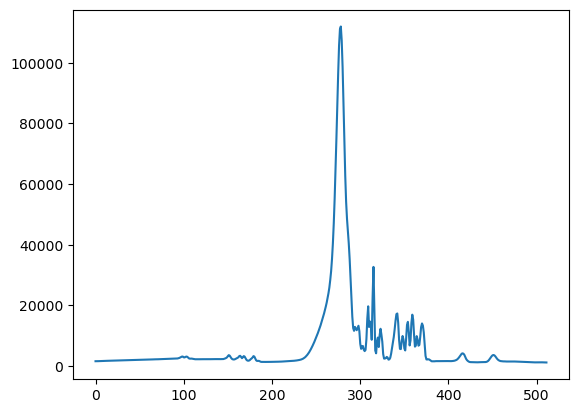

In [3]:
scan = np.array(ingaas_processing.undistort(scan, K, P, DIM))
frame_profile = np.sum(scan, axis=2)

frame_diffs = frame_profile[1:]-frame_profile[:-1]
plt.plot(np.mean(np.abs(frame_diffs), axis=0))
lom = np.argmax(np.mean(np.abs(frame_diffs), axis=0))
print(lom)

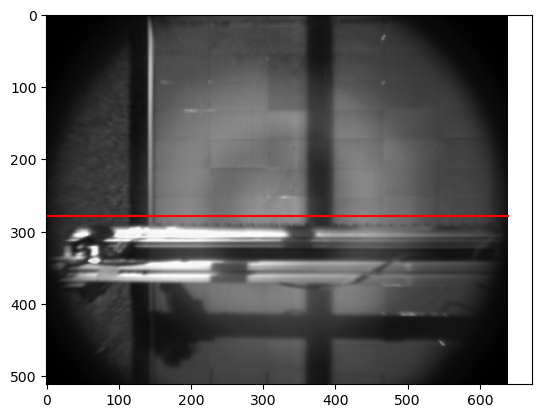

In [4]:
plt.imshow(scan[4008,:,:], cmap='gray')
plt.hlines(lom, 0, 640, "r")


In [5]:
#Functions from Jeppe
def get_phase(x, f, f_s, debug_out=False):
    '''
    Finds the phase of a given frequency in a signal, sampled at some other frequency.

    Args:
        x: The signal as a numpy array
        f: The frequency to find the phase of
        f_s: The frequency at which the signal was sampled
        debug_out: Whether to display some debug info

    Returns:
        phase: The phase of the signal
        f_out: The closest frequency present in the FFT

    '''

    # Where is the modulation frequency in the results?
    fft_frequencies = scipy.fft.fftshift(scipy.fft.rfftfreq(len(x), d=1/f_s))
    f_index = np.argmin(np.abs(f-fft_frequencies))
    f_out = fft_frequencies[f_index]
    if debug_out:
        print(f_index)
        print(f_out)

    # FFT of data
    yf = scipy.fft.fftshift(scipy.fft.rfft(x))
    if debug_out:
        plt.plot(fft_frequencies, yf)
        plt.show()


    # Get phase
    phase = np.angle(yf[f_index])
    if debug_out:
        print(yf[f_index])
        print("Phase:", phase)

    return phase, f_out

def get_extrema(f,phase,f_s,N):
    '''
    Estimate the extrema points of a discrete signal

    Args:
        f: Frequency of the signal component of interest
        phase: How the signal component is shifted. Should be in the range [-Pi,Pi]
        f_s: Frequency at which the signal is sampled
        start: Index at which to start return from
        end: Index at which to end return at

    Returns:
        peaks: Index of peaks as a numpy array
        valleys: Index of valleys as a numpy array

    '''
    peak_arg =  -phase

    if peak_arg < 0:
        peak_arg += 2*np.pi

    if peak_arg > 2*np.pi:
        peak_arg -= 2*np.pi

    valley_arg = peak_arg + np.pi

    base = np.arange(N)*2*np.pi
    peaks = np.round(f_s*(base+peak_arg)/(2*np.pi*f)).astype(np.int32)
    valleys = np.round(f_s*(base+valley_arg)/(2*np.pi*f)).astype(np.int32)

    #mask = np.all([peaks > start, peaks < end, valleys > start, valleys < end], axis=0)
    mask = np.all([peaks < N, valleys < N], axis=0)
    return peaks[mask], valleys[mask]

0.5592674192788352 49.98333333333333
[  5  11  17  23  29  35  41  47  53  59  65  71  77  83  89  95 101 107
 113 119 125 131 137 143 149 155 161 167 173 179 185 191 197 203 209 215
 221 227 233 239 245 251 257 263 269 275 281 287 293] [  8  14  20  26  32  38  44  50  56  62  68  74  80  86  92  98 104 110
 116 122 128 134 140 146 152 158 164 170 176 182 188 194 200 206 212 218
 224 230 236 242 248 254 260 266 272 278 284 290 296]


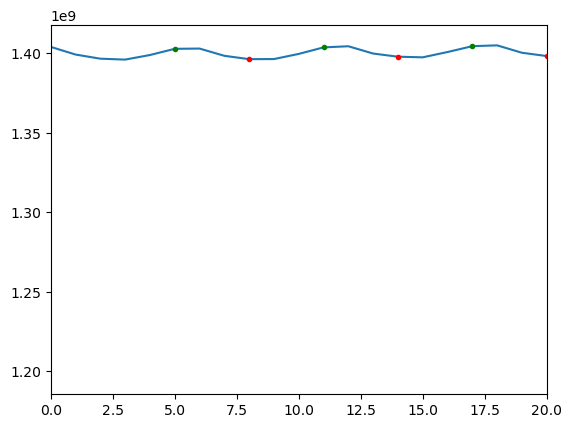

0.21586697461773183
3.2148669746177316


In [6]:
test = np.sum(scan, axis=(1,2))
#Parameters
f_m = 50 #Hz
#f_s = 300 #Hz
f_s = 299.9 #Hz

start = 0
wlen = round(f_s)
errors = []
phases = []
window = test[start:start + wlen]
#window = test
phase, f_out = get_phase(window, f_m, f_s)
errors.append((f_out-f_m)**2)
phases.append(phase)

print(phase,f_out)
peaks,valleys = get_extrema(f_m, phase, f_s, len(window))
print(peaks, valleys)
x_start=start
x_end=start+20

plt.plot(test)
plt.plot(peaks+start, test[peaks+start], ".g")
plt.plot(valleys+start, test[valleys+start], ".r")
plt.xlim(x_start, x_end)
plt.show()
# x = np.arange(len(test))
# y = np.sin(2*np.pi*x*f_m/f_s + phase) + np.cos(2*np.pi*x*f_m/f_s + phase)
# plt.xlim(x_start,x_end)
# plt.plot(x,y)
# plt.plot(peaks+start, y[peaks+start], ".g")
# plt.plot(valleys+start, y[valleys+start], ".r")
# plt.show()

print(f_s*(np.pi/4 - phase)/(2*np.pi*f_m))
print(f_s*(5*np.pi/4 - phase)/(2*np.pi*f_m))

In [10]:

imgs=scan[start:,:,:]
EL1=imgs[peaks[0]]
EL2=imgs[peaks[0]-1]
ELBG=imgs[valleys[0]]
snr = calculate_snr50_single_pixel(EL1,EL2,ELBG,lom)
print(snr)

3.139631284112699


4.176516164648959


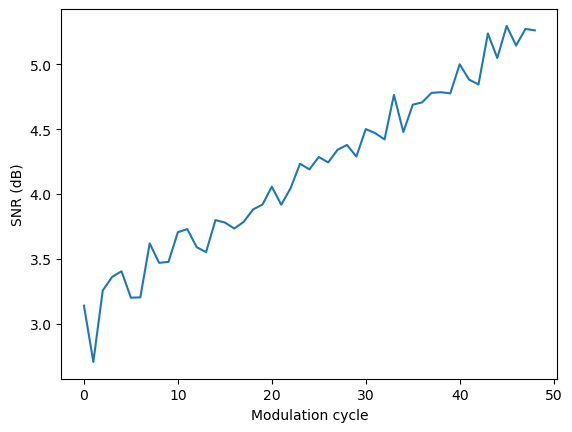

In [14]:
#Expanding to fill all modulation cycles
snr=np.zeros(len(peaks))
for i in range(len(peaks)):
    
    EL1=imgs[peaks[i]]
    EL2=imgs[peaks[i]-1]
    ELBG=imgs[valleys[i]]
    snr[i] = calculate_snr50_single_pixel(EL1,EL2,ELBG,lom)
    #print(i,snr[i])
    
avg_snr = np.mean(snr)
print(avg_snr)
plt.plot(snr)
plt.xlabel("Modulation cycle")
plt.ylabel("SNR (dB)")
plt.show() 